# Chapter 3: introduction to neural prediction: forward propagation

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- A simple network making a prediction
- What is a neural network, and what does it do?
- Making a prediction with multiple inputs
- Making a prediction with multiple outputs
- Making a prediction with multiple inputs and outputs
- Predicting on predictions

## Step 1: Predict

Chapter ini membahas prediction.

Pada chapter sebelumnya, konsep yang dipakai adalah **predict, compare, learn**. Chapter ini berfokus pada langkah pertama, yaitu **predict**.

Dalam sebuah neural network, ada tiga bagian utama saat prediction dilakukan: data, machine, dan prediction. Pada neural network pertama, prediction dilakukan untuk satu datapoint pada satu waktu. Contohnya, satu nilai input seperti jumlah rata-rata jari kaki pemain digunakan untuk menghasilkan satu prediction.

Jumlah datapoint yang diproses pada satu waktu akan memengaruhi bentuk network. Cara memilih jumlah datapoint bergantung pada apakah neural network dapat menghasilkan prediksi yang akurat dari data yang diberikan. Jika tugasnya adalah mendeteksi apakah ada kucing dalam foto, network perlu menerima semua pixel gambar sekaligus, karena satu pixel saja tidak cukup untuk menentukan apakah gambar berisi kucing.

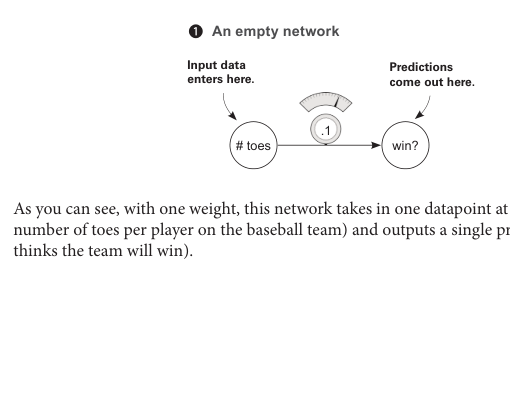

Sebelum membuat network, bentuk input dan output dataset perlu dipahami terlebih dahulu. Untuk bagian awal chapter ini, bentuk berarti jumlah kolom atau jumlah datapoint yang diproses sekaligus.

Contoh pertama menggunakan satu input datapoint dan menghasilkan satu prediction. Karena hanya ada satu input dan satu output, network dibuat dengan satu **weight** yang menghubungkan input ke output.

## A simple neural network making a prediction

Contoh pertama menggunakan neural network paling sederhana. Network menerima satu input, mengalikannya dengan satu weight, lalu menghasilkan prediction.

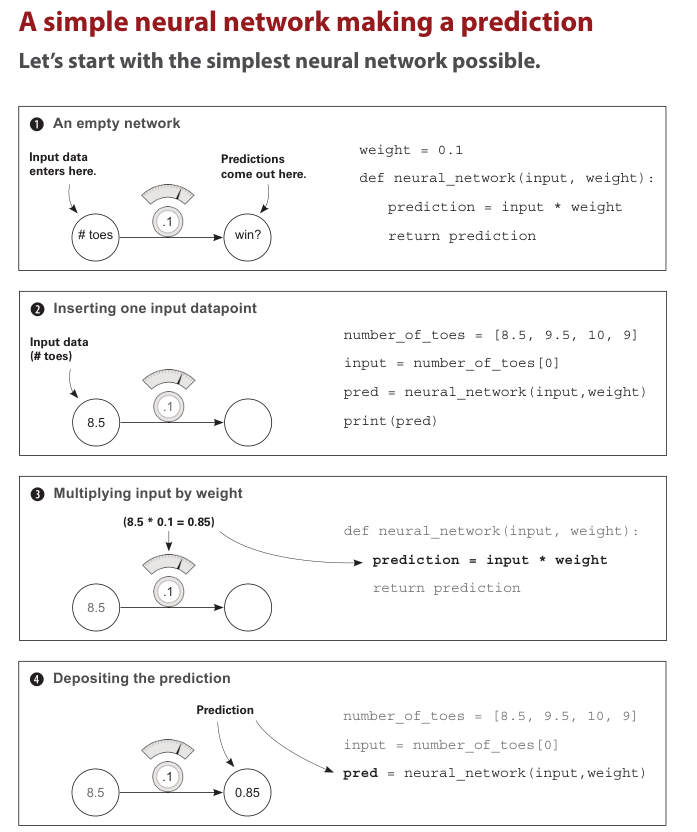

In [1]:
weight = 0.1

def neural_network(input, weight):
  prediction = input * weight
  return prediction

number_of_toes = [8.5, 9.5, 10, 9]
input = number_of_toes[0]

pred = neural_network(input, weight)
print(pred)

0.8500000000000001


## What is a neural network?

Untuk saat ini, neural network adalah satu atau lebih weights yang dikalikan dengan input data untuk membuat prediction.

**Input data** adalah angka yang dicatat dari dunia nyata. Contohnya adalah temperatur hari ini, batting average pemain baseball, atau harga saham kemarin.

**Prediction** adalah hasil yang diberikan neural network berdasarkan input data. Contohnya, berdasarkan temperatur, network memprediksi kemungkinan orang memakai pakaian tertentu, atau berdasarkan harga saham kemarin, network memprediksi harga saham hari ini.

Prediction tidak selalu benar. Neural network bisa membuat kesalahan, tetapi dapat belajar dari kesalahan tersebut. Jika prediction terlalu tinggi, network akan menyesuaikan weight agar prediction berikutnya lebih rendah. Jika prediction terlalu rendah, weight dapat disesuaikan ke arah sebaliknya.

Network belajar melalui trial and error. Pertama, network membuat prediction. Setelah itu, network melihat apakah prediction terlalu tinggi atau terlalu rendah. Terakhir, network mengubah weight agar prediction berikutnya lebih akurat untuk input yang sama.

## What does this neural network do?

Neural network sederhana ini mengalikan input dengan weight. Dengan kata lain, network melakukan scaling terhadap input.

Jika weight bernilai 2, input akan menjadi dua kali lipat. Jika weight bernilai 0.01, input akan dibagi 100. Beberapa nilai weight membuat input menjadi lebih besar, sedangkan nilai lain membuat input menjadi lebih kecil.

Interface neural network sederhana: network menerima `input` sebagai informasi, menerima `weight` sebagai pengetahuan, lalu menghasilkan `prediction`. Neural network berikutnya akan memakai input dan weight yang lebih besar dan kompleks, tetapi prinsip dasarnya tetap sama.

Dalam contoh ini, informasi yang digunakan adalah rata-rata jumlah jari kaki dalam tim baseball sebelum pertandingan. Network tidak memiliki informasi lain selain input yang diberikan. Jika setelah prediction pertama diberikan `number_of_toes[1]`, network tidak mengingat prediction sebelumnya. Neural network hanya mengetahui input yang diberikan kepadanya dan melupakan sisanya.

Cara lain untuk memahami weight adalah sebagai ukuran sensitivitas antara input network dan prediction. Jika weight sangat tinggi, input kecil dapat menghasilkan prediction yang besar. Jika weight sangat kecil, input besar tetap menghasilkan prediction kecil. Weight dapat dipahami seperti volume knob.

Pada contoh ini, network menerapkan volume knob pada variabel `number_of_toes`. Secara teori, volume knob ini dapat memberi tahu kemungkinan tim menang berdasarkan rata-rata jumlah jari kaki pemain dalam tim. Namun, baseball lebih kompleks dari itu. Karena itu, bagian berikutnya memberikan beberapa informasi sekaligus agar neural network dapat membuat keputusan yang lebih informatif.

Neural network tidak hanya dapat memprediksi angka positif. Network juga dapat memprediksi angka negatif dan menerima angka negatif sebagai input.

## Making a prediction with multiple inputs

Neural networks dapat menggabungkan informasi dari beberapa datapoint.

Network sebelumnya hanya menerima satu datapoint sebagai input dan membuat satu prediction dari datapoint tersebut. Jika hanya memakai rata-rata jumlah jari kaki pemain, prediction mungkin kurang informatif. Network dapat menerima beberapa input datapoint sekaligus, sehingga secara teori dapat membuat prediction yang lebih akurat.

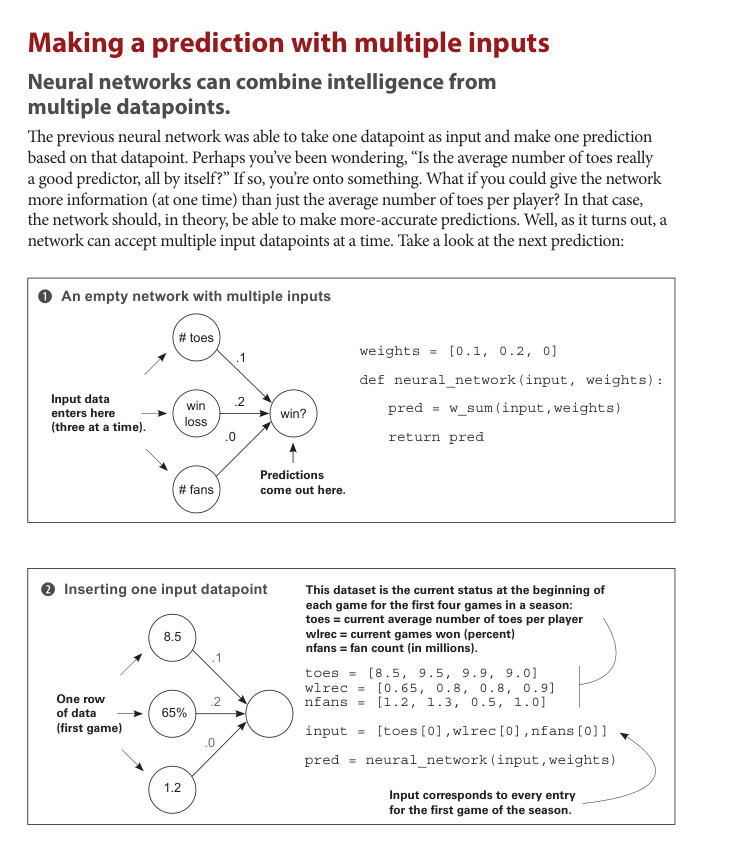

Pada contoh ini, input terdiri dari tiga data untuk game pertama:

- `toes`: rata-rata jumlah jari kaki pemain saat ini
- `wlrec`: persentase kemenangan saat ini
- `nfans`: jumlah fans dalam jutaan

Prediction dilakukan dengan menghitung weighted sum dari input dan weights.

In [2]:
def w_sum(a, b):
  assert(len(a) == len(b))
  output = 0

  for i in range(len(a)):
    output += (a[i] * b[i])

  return output

weights = [0.1, 0.2, 0]

def neural_network(input, weights):
  pred = w_sum(input, weights)
  return pred

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

input = [toes[0], wlrec[0], nfans[0]]
pred = neural_network(input, weights)
print(pred)

0.9800000000000001


## Multiple inputs: What does this neural network do?

Network dengan multiple inputs mengalikan tiga input dengan tiga weight, lalu menjumlahkan hasilnya. Proses ini disebut **weighted sum**.

Setiap input dikalikan dengan weight masing-masing. Karena ada beberapa input, setiap local prediction perlu dijumlahkan. Weighted sum juga disebut sebagai **dot product**.

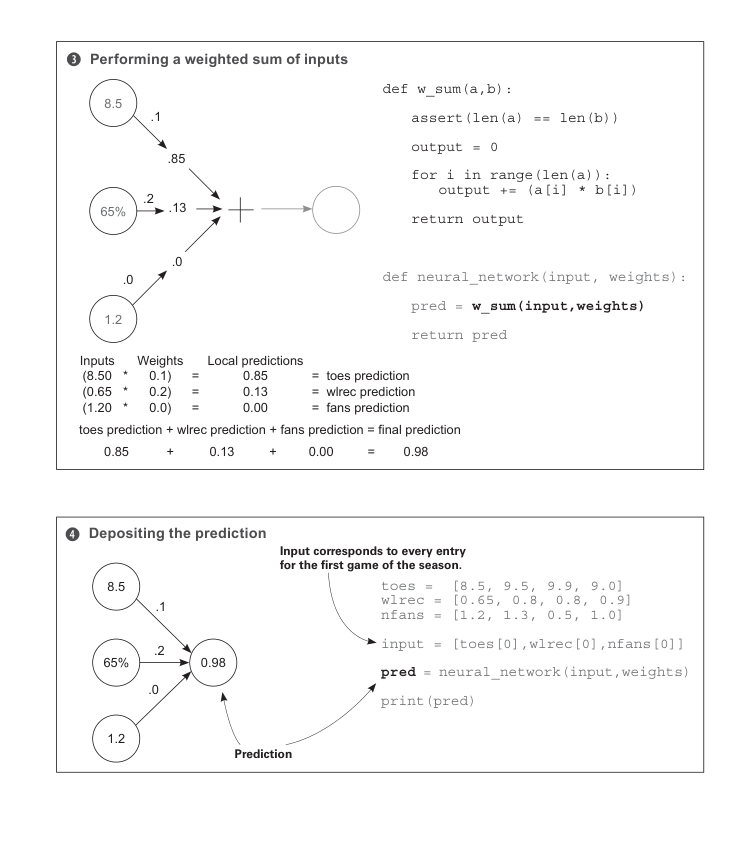

Interface neural network tetap sederhana: network menerima `input` sebagai informasi, menerima `weights` sebagai pengetahuan, lalu menghasilkan `prediction`.

Kebutuhan untuk memproses beberapa input sekaligus memperkenalkan konsep **vector**. Vector adalah daftar angka. Dalam contoh ini, `input` adalah vector dan `weights` juga vector.

Vector berguna ketika operasi dilakukan pada sekumpulan angka. Weighted sum antara dua vector dilakukan dengan mengalikan angka berdasarkan posisi yang sama, lalu menjumlahkan hasilnya.

Operasi matematika antara dua vector dengan panjang sama yang memasangkan nilai berdasarkan posisi disebut **elementwise operation**. Elementwise addition menjumlahkan dua vector berdasarkan posisi. Elementwise multiplication mengalikan dua vector berdasarkan posisi.

## Challenge: Vector math

Latihan ini meminta pembuatan fungsi berikut:

- `elementwise_multiplication(vec_a, vec_b)`
- `elementwise_addition(vec_a, vec_b)`
- `vector_sum(vec_a)`
- `vector_average(vec_a)`

Setelah itu, dua metode digunakan untuk melakukan dot product.

In [3]:
def elementwise_multiplication(vec_a, vec_b):
  assert(len(vec_a) == len(vec_b))
  output = []

  for i in range(len(vec_a)):
    output.append(vec_a[i] * vec_b[i])

  return output

def elementwise_addition(vec_a, vec_b):
  assert(len(vec_a) == len(vec_b))
  output = []

  for i in range(len(vec_a)):
    output.append(vec_a[i] + vec_b[i])

  return output

def vector_sum(vec_a):
  output = 0

  for i in range(len(vec_a)):
    output += vec_a[i]

  return output

def vector_average(vec_a):
  return vector_sum(vec_a) / len(vec_a)

def dot_product(vec_a, vec_b):
  return vector_sum(elementwise_multiplication(vec_a, vec_b))

a = [1, 2, 3]
b = [4, 5, 6]

print("elementwise_multiplication:", elementwise_multiplication(a, b))
print("elementwise_addition:", elementwise_addition(a, b))
print("vector_sum:", vector_sum(a))
print("vector_average:", vector_average(a))
print("dot_product:", dot_product(a, b))

elementwise_multiplication: [4, 10, 18]
elementwise_addition: [5, 7, 9]
vector_sum: 6
vector_average: 2.0
dot_product: 32


Weighted sum atau dot product memberi gambaran tentang similarity antara dua vector. Jika dua vector memiliki overlap weight yang tinggi, weighted sum akan lebih tinggi. Jika tidak ada overlap weight, nilainya dapat menjadi nol. Jika ada weight negatif, nilai tersebut dapat menurunkan skor.

Dot product kadang dapat dipahami seperti logical AND. Jika dua posisi pada vector sama-sama memiliki nilai, skor naik. Jika salah satu bernilai negatif, skor dapat turun. Dengan cara kasar, weight dapat dibaca sebagai bentuk kondisi terhadap input.

Dalam prediction, network memberi skor tinggi ketika input cukup mirip dengan weights. Pada contoh baseball, `nfans` diabaikan karena weight-nya 0. Predictor yang paling sensitif adalah `wlrec` karena weight-nya 0.2. Namun, kontribusi terbesar pada skor berasal dari `ntoes`, karena kombinasi input dan weight-nya paling tinggi.

Weights tidak bisa diacak karena setiap weight memiliki posisi tertentu. Nilai weight dan nilai input sama-sama menentukan dampak terhadap skor akhir. Weight negatif dapat membuat beberapa input mengurangi prediction akhir.

## Multiple inputs: Complete runnable code

Potongan kode sebelumnya digabungkan menjadi kode lengkap yang membuat dan menjalankan neural network.

In [4]:
def w_sum(a, b):
  assert(len(a) == len(b))
  output = 0

  for i in range(len(a)):
    output += (a[i] * b[i])

  return output

weights = [0.1, 0.2, 0]

def neural_network(input, weights):
  pred = w_sum(input, weights)
  return pred

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

input = [toes[0], wlrec[0], nfans[0]]
pred = neural_network(input, weights)
print(pred)

0.9800000000000001


NumPy adalah library Python untuk numerical Python. NumPy memiliki kode yang efisien untuk membuat vector dan menjalankan fungsi umum seperti dot products.

Kode berikut adalah versi NumPy dari network sebelumnya.

In [5]:
import numpy as np

weights = np.array([0.1, 0.2, 0])

def neural_network(input, weights):
  pred = input.dot(weights)
  return pred

toes = np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65, 0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])

input = np.array([toes[0], wlrec[0], nfans[0]])
pred = neural_network(input, weights)
print(pred)

0.9800000000000001


Kedua network tersebut menghasilkan `0.98`. Pada kode NumPy, fungsi `w_sum` tidak perlu dibuat karena NumPy memiliki fungsi `dot`.

## Making a prediction with multiple outputs

Neural networks juga dapat membuat beberapa prediction dari satu input.

Prediction terjadi seperti tiga neural network single-weight yang tidak saling terhubung. Dalam contoh ini, network tidak hanya memprediksi apakah tim menang atau kalah, tetapi juga memprediksi apakah pemain sedih dan persentase pemain yang cedera. Prediction dibuat hanya menggunakan win/loss record saat ini.

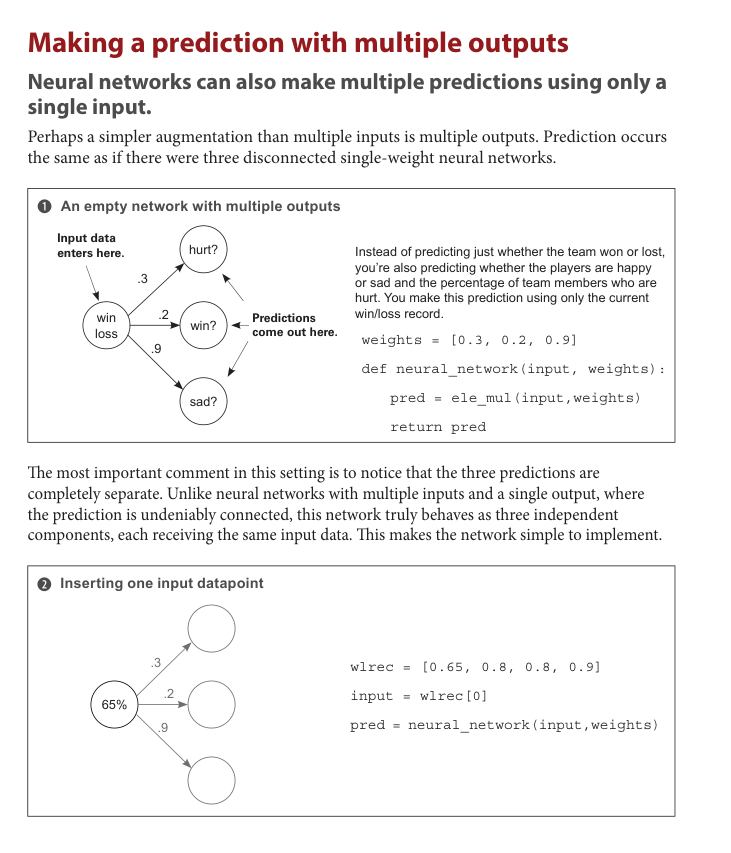

Tiga prediction tersebut terpisah sepenuhnya. Network ini bertindak seperti tiga komponen independen yang masing-masing menerima input data yang sama.

In [6]:
weights = [0.3, 0.2, 0.9]

def ele_mul(number, vector):
  output = [0, 0, 0]
  assert(len(output) == len(vector))

  for i in range(len(vector)):
    output[i] = number * vector[i]

  return output

def neural_network(input, weights):
  pred = ele_mul(input, weights)
  return pred

wlrec = [0.65, 0.8, 0.8, 0.9]
input = wlrec[0]

pred = neural_network(input, weights)
print(pred)

[0.195, 0.13, 0.5850000000000001]


Pada bagian ini, kode di buku menggunakan `weight` pada pemanggilan fungsi, tetapi variabel yang benar adalah `weights`. Notebook ini memakai `weights` agar kode dapat berjalan.

## Predicting with multiple inputs and outputs

Neural networks dapat memprediksi beberapa output dari beberapa input.

Network dengan multiple inputs dan network dengan multiple outputs dapat digabungkan menjadi network yang memiliki multiple inputs dan multiple outputs. Seperti sebelumnya, weight menghubungkan setiap input node ke setiap output node, lalu prediction dilakukan dengan cara yang sama.

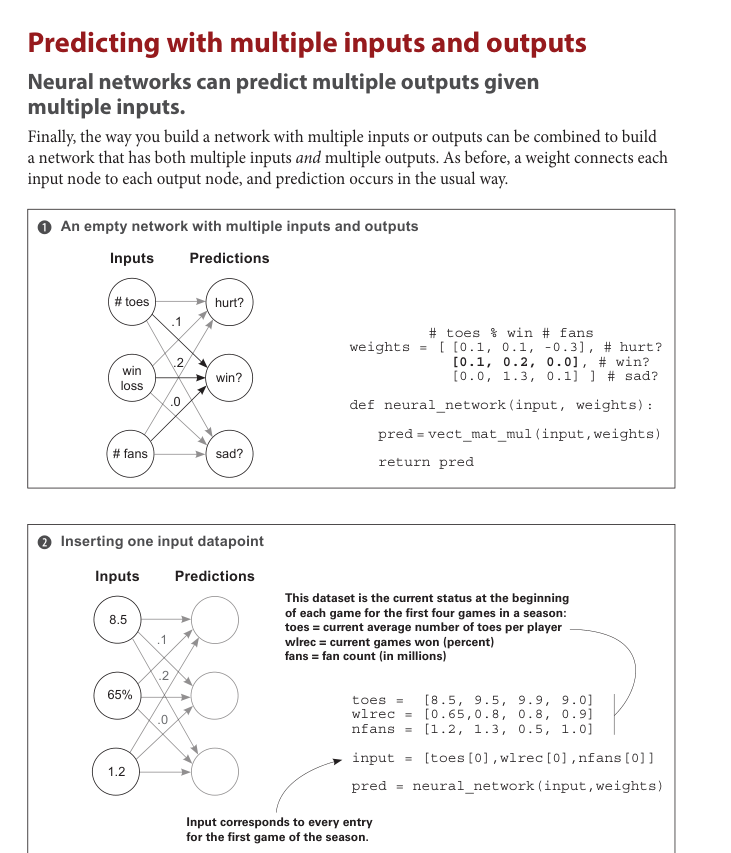

Setiap output dibuat dari weighted sum input. Dalam contoh ini, output yang diprediksi adalah `hurt`, `win`, dan `sad`.

In [7]:
def w_sum(a, b):
  assert(len(a) == len(b))
  output = 0

  for i in range(len(a)):
    output += (a[i] * b[i])

  return output

def vect_mat_mul(vect, matrix):
  assert(len(vect) == len(matrix[0]))
  output = [0, 0, 0]

  for i in range(len(matrix)):
    output[i] = w_sum(vect, matrix[i])

  return output

weights = [
  [0.1, 0.1, -0.3], # hurt?
  [0.1, 0.2, 0.0],  # win?
  [0.0, 1.3, 0.1]   # sad?
]

def neural_network(input, weights):
  pred = vect_mat_mul(input, weights)
  return pred

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

input = [toes[0], wlrec[0], nfans[0]]
pred = neural_network(input, weights)
print(pred)

[0.555, 0.9800000000000001, 0.9650000000000001]


Pada bagian ini, kode di buku menampilkan `weight` pada pemanggilan fungsi, tetapi variabel yang digunakan adalah `weights`. Selain itu, fungsi `vect_mat_mul` perlu memeriksa panjang vector terhadap panjang setiap row matrix agar sesuai dengan bentuk data yang dipakai. Notebook ini memakai bentuk tersebut agar kode berjalan.

## Multiple inputs and outputs: How does it work?

Network ini melakukan tiga weighted sum independen terhadap input untuk menghasilkan tiga prediction.

Arsitektur ini dapat dipahami sebagai tiga dot products independen. Setiap output node mengambil weighted sum sendiri dari input dan menghasilkan prediction sendiri.

Fungsi `vect_mat_mul` melakukan iterasi pada setiap row weights. Setiap row adalah vector. Fungsi tersebut membuat prediction menggunakan `w_sum`, lalu menyimpan hasilnya dalam vector `output`.

Daftar vector disebut **matrix**. Operasi yang dilakukan pada bagian ini disebut **vector-matrix multiplication**. Operasi tersebut mengambil sebuah vector dan menjalankan dot product dengan setiap row dalam sebuah matrix.

## Predicting on predictions

Neural networks dapat ditumpuk.

Output dari satu network dapat dijadikan input untuk network lain. Hasilnya adalah dua vector-matrix multiplication berturut-turut. Cara ini berguna karena beberapa dataset memiliki pola yang terlalu kompleks untuk satu weight matrix.

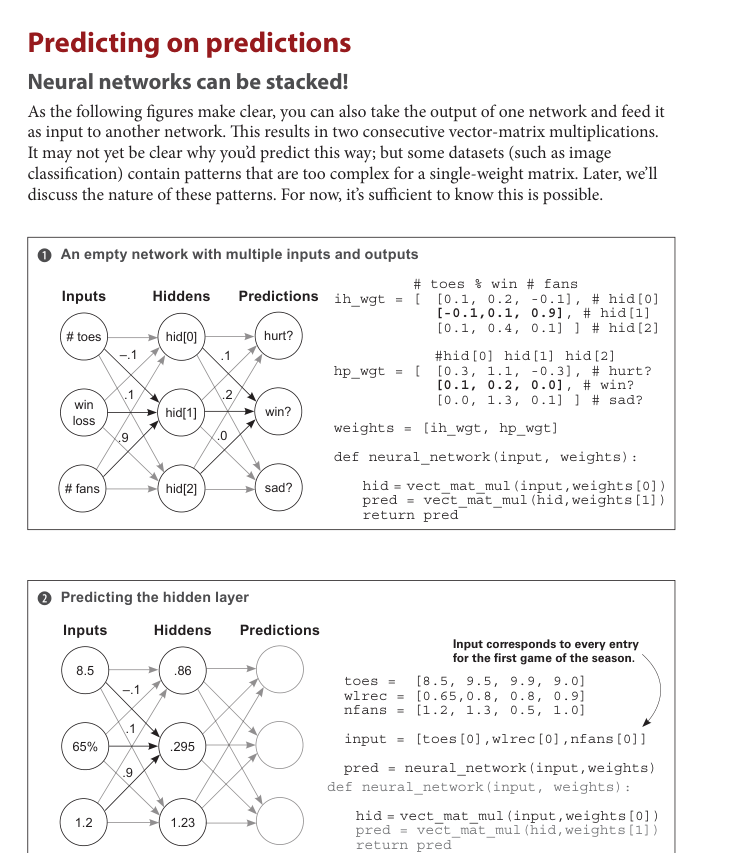

Pada contoh ini, input diproses menjadi hidden layer terlebih dahulu, lalu hidden layer diproses lagi menjadi prediction akhir.

In [8]:
def w_sum(a, b):
  assert(len(a) == len(b))
  output = 0

  for i in range(len(a)):
    output += (a[i] * b[i])

  return output

def vect_mat_mul(vect, matrix):
  assert(len(vect) == len(matrix[0]))
  output = [0 for _ in range(len(matrix))]

  for i in range(len(matrix)):
    output[i] = w_sum(vect, matrix[i])

  return output

ih_wgt = [
  [0.1, 0.2, -0.1],  # hid[0]
  [-0.1, 0.1, 0.9],  # hid[1]
  [0.1, 0.4, 0.1]    # hid[2]
]

hp_wgt = [
  [0.3, 1.1, -0.3], # hurt?
  [0.1, 0.2, 0.0],  # win?
  [0.0, 1.3, 0.1]   # sad?
]

weights = [ih_wgt, hp_wgt]

def neural_network(input, weights):
  hid = vect_mat_mul(input, weights[0])
  pred = vect_mat_mul(hid, weights[1])
  return pred

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

input = [toes[0], wlrec[0], nfans[0]]
pred = neural_network(input, weights)
print(pred)

[0.21350000000000002, 0.14500000000000002, 0.5065]


Kode berikut melakukan operasi yang sama menggunakan NumPy. Library seperti NumPy membuat kode lebih cepat serta lebih mudah dibaca dan ditulis.

In [9]:
import numpy as np

ih_wgt = np.array([
  [0.1, 0.2, -0.1],  # hid[0]
  [-0.1, 0.1, 0.9],  # hid[1]
  [0.1, 0.4, 0.1]
]).T

hp_wgt = np.array([
  [0.3, 1.1, -0.3], # hurt?
  [0.1, 0.2, 0.0],  # win?
  [0.0, 1.3, 0.1]
]).T

weights = [ih_wgt, hp_wgt]

def neural_network(input, weights):
  hid = input.dot(weights[0])
  pred = hid.dot(weights[1])
  return pred

toes = np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65, 0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])

input = np.array([toes[0], wlrec[0], nfans[0]])
pred = neural_network(input, weights)
print(pred)

[0.2135 0.145  0.5065]


## A quick primer on NumPy

NumPy membantu pembuatan vector dan matrix, serta menjalankan operasi seperti dot products, elementwise multiplication, elementwise addition, dan vector-matrix multiplication.

Untuk sementara, fungsi Python dasar tetap digunakan agar isi operasi lebih terlihat. Namun, NumPy juga diperkenalkan karena chapter berikutnya akan bergerak menuju penggunaan NumPy.

Vector dan matrix dapat dibuat dengan beberapa cara. Proses membuat vector dan matrix pada NumPy mirip. Jika matrix dibuat hanya dengan satu row, itu adalah vector. Dalam format matrix, urutannya adalah `(rows, columns)`.

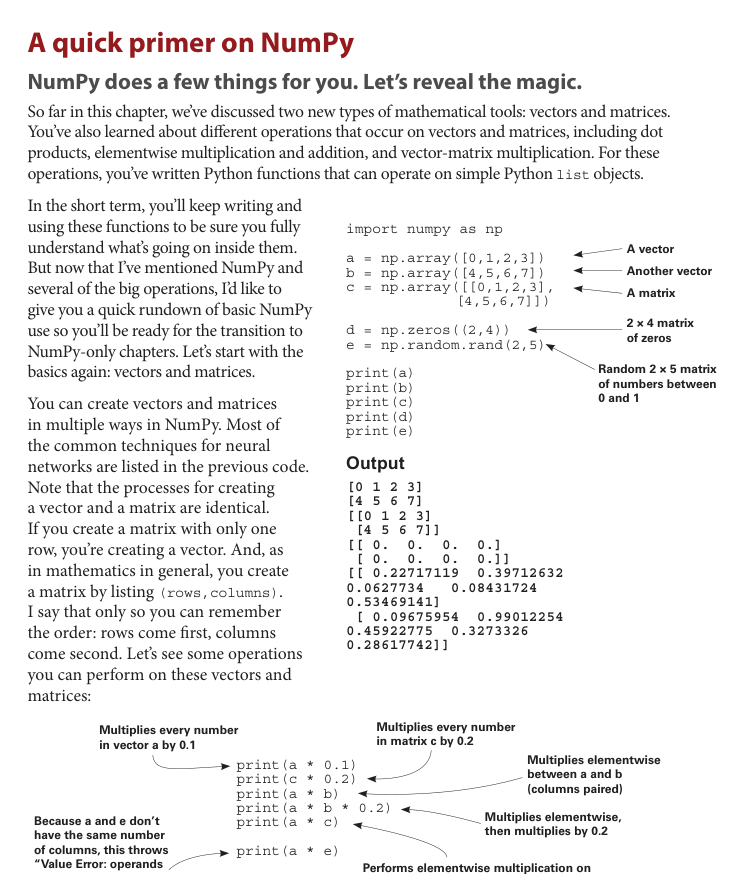

In [10]:
import numpy as np

a = np.array([0, 1, 2, 3])
b = np.array([4, 5, 6, 7])
c = np.array([
  [0, 1, 2, 3],
  [4, 5, 6, 7]
])
d = np.zeros((2, 4))
e = np.random.rand(2, 5)

print(a)
print(b)
print(c)
print(d)
print(e)

[0 1 2 3]
[4 5 6 7]
[[0 1 2 3]
 [4 5 6 7]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0.47665143 0.44366124 0.14857931 0.67437314 0.56044019]
 [0.2740526  0.2434854  0.14189633 0.82855385 0.42553983]]


Operasi `*` pada NumPy otomatis mendeteksi tipe variabel dan mencoba menentukan operasi yang sesuai.

Aturan umum untuk operasi elementwise seperti `+`, `-`, `*`, dan `/` adalah kedua variabel harus memiliki jumlah kolom yang sama, atau salah satu variabel hanya memiliki satu kolom.

Jika vector dikalikan scalar, setiap nilai dalam vector dikalikan dengan scalar tersebut. Jika matrix dikalikan scalar, setiap elemen matrix dikalikan scalar tersebut. Jika dua vector memiliki jumlah kolom yang sama, NumPy mengalikan setiap elemen berdasarkan posisinya.

In [11]:
print(a * 0.1)
print(c * 0.2)
print(a * b)
print(a * b * 0.2)
print(a * c)

[0.  0.1 0.2 0.3]
[[0.  0.2 0.4 0.6]
 [0.8 1.  1.2 1.4]]
[ 0  5 12 21]
[0.  1.  2.4 4.2]
[[ 0  1  4  9]
 [ 0  5 12 21]]


Pada buku, operasi `a * e` ditampilkan sebagai contoh yang menghasilkan error karena `a` dan `e` tidak memiliki jumlah kolom yang sama. Agar notebook tetap bisa di-run sampai selesai, error tersebut ditangani dengan `try-except`.

In [12]:
try:
  print(a * e)
except ValueError as error:
  print("ValueError:", error)

ValueError: operands could not be broadcast together with shapes (4,) (2,5) 


Untuk membaca kode NumPy, ada dua hal yang harus diperhatikan: operasi yang digunakan dan shape dari setiap variabel. Shape menunjukkan jumlah rows dan columns.

Pada matrix multiplication dengan `dot`, aturan utamanya adalah shape harus sejajar. Columns dari matrix kiri harus sama dengan rows dari matrix kanan. Jika bentuknya `(a, b).dot(b, c)`, output-nya berbentuk `(a, c)`.

In [13]:
a = np.zeros((1, 4))
b = np.zeros((4, 3))
c = a.dot(b)

print(c.shape)

(1, 3)


In [14]:
a = np.zeros((2, 4))
b = np.zeros((4, 3))
c = a.dot(b)
print(c.shape)

e = np.zeros((2, 1))
f = np.zeros((1, 3))
g = e.dot(f)
print(g.shape)

h = np.zeros((5, 4)).T
i = np.zeros((5, 6))
j = h.dot(i)
print(j.shape)

(2, 3)
(2, 3)
(4, 6)


Pada buku, contoh terakhir `h.dot(i)` dengan shape `(5, 4)` dan `(5, 6)` menghasilkan error karena columns pada matrix kiri tidak sama dengan rows pada matrix kanan. Agar notebook tetap bisa di-run sampai selesai, error tersebut ditangani dengan `try-except`.

In [15]:
h = np.zeros((5, 4))
i = np.zeros((5, 6))

try:
  j = h.dot(i)
  print(j.shape)
except ValueError as error:
  print("ValueError:", error)

ValueError: shapes (5,4) and (5,6) not aligned: 4 (dim 1) != 5 (dim 0)


## Summary

Untuk melakukan prediction, neural networks menjalankan weighted sums berulang terhadap input.

Chapter ini menunjukkan beberapa bentuk neural networks yang semakin kompleks. Aturan yang dipakai sebenarnya sedikit dan sederhana, tetapi digunakan berulang untuk membangun network yang lebih besar dan lebih maju. Intelligence dari network bergantung pada nilai weight yang diberikan.

Semua yang dilakukan dalam chapter ini adalah bentuk **forward propagation**, yaitu saat neural network menerima input data dan membuat prediction. Istilah ini digunakan karena activations dipropagasikan maju melalui network. Pada contoh-contoh ini, activations adalah semua angka yang bukan weights dan unik untuk setiap prediction.

Chapter berikutnya membahas cara mengatur weights agar neural networks dapat membuat prediction yang akurat.